# Marketing × Sales Analysis

Цель анализа — сопоставить маркетинговые события с продажами и оценить,
как меняются продажи после маркетинговых активностей.

Важно:
- историческая атрибуция пользователей недоступна;
- рост продаж после события не доказывает причинный эффект;
- результаты ниже интерпретируются как наблюдаемая ассоциация маркетинга и продаж;
- продажи доступны только с 04.08.2026, поэтому анализ проводится только на пересекающемся временном диапазоне.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [3]:
SALES_PATH = Path("../data/raw/base.xlsx")
MARKETING_PATH = Path("../data/raw/marketing_history.xlsx")

In [4]:
sales = pd.read_excel(
    SALES_PATH,
    sheet_name="Данные"
)

sales = sales.rename(columns={
    "Номер студента": "student_id",
    "Сумма": "amount",
    "Курс": "course",
    "Время": "timestamp",
})

sales["timestamp"] = pd.to_datetime(
    sales["timestamp"],
    errors="coerce"
)

sales.head()

,student_id,amount,course,timestamp
0,437,"8,950.00",ML про,2026-08-04 09:08:31
1,437,"7,890.00",Аналитика старт,2026-08-04 09:35:00
2,443,"8,475.00",Линейная алгебра,2026-08-04 10:14:38
3,443,"8,475.00",Мат анализ,2026-08-04 10:14:38
4,430,"8,950.00",К ВУЗу,2026-08-04 13:38:06


In [5]:
marketing = pd.read_excel(
    MARKETING_PATH,
    header=2
)

marketing["event_time"] = pd.to_datetime(
    marketing["event_time"],
    errors="coerce"
)

marketing.head()

,event_id,event_time,source_channel,activity_type,course,campaign,placement,creative_text,external_or_internal,post_url,views,reactions,cost_rub,data_source,confidence,collected_by,notes,channel_relationship,paid_status,raw_origin,raw_category,raw_period,raw_media,raw_forwarded_from,raw_links,raw_promo_candidate,raw_offer_flag,raw_discount_flag,raw_launch_flag,raw_lead_magnet_flag,raw_ad_marking,raw_erid,raw_scraped_at,raw_html_ref,Unnamed: 34,product_scope,product_line,inferred_course,content_direction,candidate_courses
0,INT-1764,2026-07-01 18:10:49,@postypashki_old,Контент с предложением курсов (авто),ML старт | Data Science,NaN,postypashki_old/1764,Самые интересные события в ближайшее время.\nВ...,internal,https://t.me/postypashki_old/1764,21200,42.00,NaN,Telegram,raw,Codex,Самые интересные события в ближайшее время. Вс...,internal,unknown,telegram_internal,Контент с предложением курсов (авто),Предыстория,NaN,NaN,NaN,NaN,1.00,0.00,0.00,0.00,NaN,False,2026-07-01T15:10:49+00:00,NaN,NaN,multiple_courses,START,NaN,career,ML старт | Data science
1,INT-1765,2026-07-02 18:31:22,@postypashki_old,Прочий контент (авто),NaN,NaN,postypashki_old/1765,"В новом ролике обсудим, что с вашей психикой с...",internal,https://t.me/postypashki_old/1765,17500,50.00,NaN,Telegram,raw,Codex,"В новом ролике обсудим, что с вашей психикой с...",internal,unknown,telegram_internal,Прочий контент (авто),Предыстория,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,NaN,False,2026-07-02T15:31:22+00:00,NaN,NaN,unknown,NaN,NaN,career,NaN
2,INT-1767,2026-07-04 12:03:55,@postypashki_old,Промо со скидкой (авто),NaN,NaN,postypashki_old/1767,❗️ Завтра заканчивается донабор на стажировку ...,internal,https://t.me/postypashki_old/1767,18600,25.00,NaN,Telegram,raw,Codex,❗️ Завтра заканчивается донабор на стажировку ...,internal,unknown,telegram_internal,Промо со скидкой (авто),Предыстория,NaN,NaN,NaN,NaN,1.00,1.00,0.00,0.00,NaN,False,2026-07-04T09:03:55+00:00,NaN,NaN,product_line,START,NaN,career,Аналитика старт | Алгоритмы старт | Backend ст...
3,INT-1768,2026-07-04 15:35:53,@postypashki_old,Контент с предложением курсов (авто),ML старт,NaN,postypashki_old/1768,Академия Авито и Буткем Авито \n\nСегодня прош...,internal,https://t.me/postypashki_old/1768,20400,26.00,NaN,Telegram,raw,Codex,Академия Авито и Буткем Авито Сегодня прошел п...,internal,unknown,telegram_internal,Контент с предложением курсов (авто),Предыстория,NaN,NaN,NaN,NaN,1.00,0.00,0.00,0.00,NaN,False,2026-07-04T12:35:53+00:00,NaN,NaN,single_course,START,ML старт,ml,ML старт
4,INT-1770,2026-07-05 16:51:14,@postypashki_old,Прочий контент (авто),ML старт,NaN,postypashki_old/1770,Как затащить МЛ собеседование в 2026 году \n\n...,internal,https://t.me/postypashki_old/1770,19000,36.00,NaN,Telegram,raw,Codex,Как затащить МЛ собеседование в 2026 году В ве...,internal,unknown,telegram_internal,Прочий контент (авто),Предыстория,NaN,NaN,NaN,NaN,0.00,1.00,0.00,0.00,NaN,False,2026-07-05T13:51:14+00:00,NaN,NaN,single_course,START,ML старт,ml,ML старт


## 1. Временной диапазон

Сначала определим пересечение доступной истории маркетинга и продаж.

In [6]:
print(
    "Продажи:",
    sales["timestamp"].min(),
    "—",
    sales["timestamp"].max()
)

print(
    "Маркетинг:",
    marketing["event_time"].min(),
    "—",
    marketing["event_time"].max()
)

Продажи: 2026-08-04 09:08:31 — 2026-09-10 06:09:12
Маркетинг: 2026-07-01 18:10:49 — 2026-09-10 17:36:13


In [7]:
analysis_start = sales["timestamp"].min().normalize()
analysis_end = sales["timestamp"].max().normalize()

analysis_start, analysis_end

(Timestamp('2026-08-04 00:00:00'), Timestamp('2026-09-10 00:00:00'))

In [8]:
marketing_overlap = marketing[
    (marketing["event_time"] >= analysis_start) &
    (marketing["event_time"] <= analysis_end)
].copy()

print(
    "Маркетинговых событий в общем периоде:",
    len(marketing_overlap)
)

Маркетинговых событий в общем периоде: 136


In [9]:
sorted(sales["course"].dropna().unique())

['AI агенты',
 'Backend про',
 'Backend старт',
 'Data Engenering',
 'Data Science',
 'ML про',
 'ML старт',
 'АВ тестам',
 'Алгоритмы',
 'Алгоритмы про',
 'Алгоритмы старт',
 'Аналитика про',
 'Аналитика старт',
 'Дискретка',
 'К ВУЗу',
 'Линейная алгебра',
 'Мат анализ',
 'Теория вероятностей']

In [10]:
sorted(
    marketing_overlap["candidate_courses"]
    .dropna()
    .unique()
)

['AI-агенты про',
 'AI-агенты про | ML про',
 'AI-агенты про | А/В-тесты',
 'AI-агенты про | Алгоритмы про | Backend про',
 'AI-агенты про | Алгоритмы про | ML про',
 'AI-агенты про | Алгоритмы про | Аналитика про',
 'AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про',
 'AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про | А/В-тесты',
 'Backend про',
 'Backend старт',
 'Backend старт | Backend про',
 'ML про',
 'А/В-тесты',
 'Алгоритмы про',
 'Алгоритмы про | Backend про',
 'Алгоритмы старт',
 'Алгоритмы старт | ML старт',
 'Аналитика про',
 'Аналитика старт',
 'Аналитика старт | Алгоритмы старт | Backend старт | ML старт',
 'Аналитика старт | Аналитика про',
 'Аналитика старт | Аналитика про | А/В-тесты']

In [12]:
course_mapping = {
    "AI агенты": "AI-агенты про",
    "АВ тестам": "А/В-тесты",
}

In [13]:
sales["course_normalized"] = (
    sales["course"]
    .replace(course_mapping)
    .str.strip()
)

In [14]:
sorted(sales["course_normalized"].dropna().unique())

['AI-агенты про',
 'Backend про',
 'Backend старт',
 'Data Engenering',
 'Data Science',
 'ML про',
 'ML старт',
 'А/В-тесты',
 'Алгоритмы',
 'Алгоритмы про',
 'Алгоритмы старт',
 'Аналитика про',
 'Аналитика старт',
 'Дискретка',
 'К ВУЗу',
 'Линейная алгебра',
 'Мат анализ',
 'Теория вероятностей']

In [15]:
marketing_courses = (
    marketing_overlap[
        [
            "event_id",
            "event_time",
            "activity_type",
            "external_or_internal",
            "product_scope",
            "product_line",
            "content_direction",
            "candidate_courses",
        ]
    ]
    .dropna(subset=["candidate_courses"])
    .assign(
        candidate_course=lambda x:
        x["candidate_courses"].str.split(r"\s*\|\s*")
    )
    .explode("candidate_course")
    .reset_index(drop=True)
)

marketing_courses["candidate_course"] = (
    marketing_courses["candidate_course"]
    .str.strip()
)

In [16]:
sorted(marketing_courses["candidate_course"].unique())

['AI-агенты про',
 'Backend про',
 'Backend старт',
 'ML про',
 'ML старт',
 'А/В-тесты',
 'Алгоритмы про',
 'Алгоритмы старт',
 'Аналитика про',
 'Аналитика старт']

In [17]:
sales_courses = set(
    sales["course_normalized"]
    .dropna()
    .unique()
)

marketing_courses_set = set(
    marketing_courses["candidate_course"]
    .dropna()
    .unique()
)

print("Есть и в продажах, и в маркетинге:")
print(sorted(sales_courses & marketing_courses_set))

print("\nЕсть в продажах, но нет в маркетинге:")
print(sorted(sales_courses - marketing_courses_set))

print("\nЕсть в маркетинге, но нет в продажах:")
print(sorted(marketing_courses_set - sales_courses))

Есть и в продажах, и в маркетинге:
['AI-агенты про', 'Backend про', 'Backend старт', 'ML про', 'ML старт', 'А/В-тесты', 'Алгоритмы про', 'Алгоритмы старт', 'Аналитика про', 'Аналитика старт']

Есть в продажах, но нет в маркетинге:
['Data Engenering', 'Data Science', 'Алгоритмы', 'Дискретка', 'К ВУЗу', 'Линейная алгебра', 'Мат анализ', 'Теория вероятностей']

Есть в маркетинге, но нет в продажах:
[]


In [20]:
sales["date"] = sales["timestamp"].dt.floor("D")

sales_daily = (
    sales
    .groupby(
        ["date", "course_normalized"],
        as_index=False
    )
    .agg(
        transactions=("student_id", "size"),
        buyers=("student_id", "nunique"),
        revenue=("amount", "sum"),
    )
)

sales_daily.head()

,date,course_normalized,transactions,buyers,revenue
0,2026-08-04,Backend старт,1,1,"8,745.00"
1,2026-08-04,Data Science,1,1,"15,695.00"
2,2026-08-04,ML про,2,2,"17,425.00"
3,2026-08-04,ML старт,1,1,"8,475.00"
4,2026-08-04,Аналитика старт,1,1,"7,890.00"


In [21]:
WINDOW_BEFORE = 3
WINDOW_AFTER = 3

def get_sales_window(event_row, sales_daily):
    event_date = event_row["event_time"].floor("D")
    course = event_row["candidate_course"]

    course_sales = sales_daily[
        sales_daily["course_normalized"] == course
    ].copy()

    before = course_sales[
        (course_sales["date"] >= event_date - pd.Timedelta(days=WINDOW_BEFORE)) &
        (course_sales["date"] < event_date)
    ]

    event_day = course_sales[
        course_sales["date"] == event_date
    ]

    after = course_sales[
        (course_sales["date"] > event_date) &
        (course_sales["date"] <= event_date + pd.Timedelta(days=WINDOW_AFTER))
    ]

    return pd.Series({
        "event_date": event_date,

        "transactions_before": before["transactions"].sum(),
        "buyers_before": before["buyers"].sum(),
        "revenue_before": before["revenue"].sum(),

        "transactions_d0": event_day["transactions"].sum(),
        "buyers_d0": event_day["buyers"].sum(),
        "revenue_d0": event_day["revenue"].sum(),

        "transactions_after": after["transactions"].sum(),
        "buyers_after": after["buyers"].sum(),
        "revenue_after": after["revenue"].sum(),
    })

In [22]:
window_metrics = marketing_courses.apply(
    get_sales_window,
    axis=1,
    sales_daily=sales_daily
)

event_sales = pd.concat(
    [
        marketing_courses.reset_index(drop=True),
        window_metrics
    ],
    axis=1
)

event_sales.head()

,event_id,event_time,activity_type,external_or_internal,product_scope,product_line,content_direction,candidate_courses,candidate_course,event_date,transactions_before,buyers_before,revenue_before,transactions_d0,buyers_d0,revenue_d0,transactions_after,buyers_after,revenue_after
0,INT-1833,2026-08-07 17:22:16,Контент с предложением курсов (авто),internal,single_course,START,algorithms,Алгоритмы старт,Алгоритмы старт,2026-08-07,0,0,0.00,0,0,0.00,49,49,"250,941.68"
1,INT-1836,2026-08-09 13:32:11,Промо со скидкой (авто),internal,product_line,START,career,Аналитика старт | Алгоритмы старт | Backend ст...,Аналитика старт,2026-08-09,7,7,"39,360.00",17,17,"100,770.00",17,17,"106,020.00"
2,INT-1836,2026-08-09 13:32:11,Промо со скидкой (авто),internal,product_line,START,career,Аналитика старт | Алгоритмы старт | Backend ст...,Алгоритмы старт,2026-08-09,14,14,"72,565.00",28,28,"142,186.68",12,12,"60,940.00"
3,INT-1836,2026-08-09 13:32:11,Промо со скидкой (авто),internal,product_line,START,career,Аналитика старт | Алгоритмы старт | Backend ст...,Backend старт,2026-08-09,8,8,"45,850.00",12,12,"67,226.66",2,2,"9,650.00"
4,INT-1836,2026-08-09 13:32:11,Промо со скидкой (авто),internal,product_line,START,career,Аналитика старт | Алгоритмы старт | Backend ст...,ML старт,2026-08-09,10,10,"56,375.00",20,20,"107,298.33",15,15,"92,710.00"


In [23]:
event_sales["avg_transactions_before"] = (
    event_sales["transactions_before"] / WINDOW_BEFORE
)

event_sales["avg_transactions_after"] = (
    event_sales["transactions_after"] / WINDOW_AFTER
)

event_sales["avg_revenue_before"] = (
    event_sales["revenue_before"] / WINDOW_BEFORE
)

event_sales["avg_revenue_after"] = (
    event_sales["revenue_after"] / WINDOW_AFTER
)

In [24]:
event_sales["uplift_transactions_abs"] = (
    event_sales["avg_transactions_after"] -
    event_sales["avg_transactions_before"]
)

event_sales["uplift_revenue_abs"] = (
    event_sales["avg_revenue_after"] -
    event_sales["avg_revenue_before"]
)

In [25]:
event_sales[
    [
        "event_id",
        "event_date",
        "candidate_course",
        "activity_type",
        "avg_transactions_before",
        "avg_transactions_after",
        "uplift_transactions_abs",
        "avg_revenue_before",
        "avg_revenue_after",
        "uplift_revenue_abs",
    ]
].head(20)

,event_id,event_date,candidate_course,activity_type,avg_transactions_before,avg_transactions_after,uplift_transactions_abs,avg_revenue_before,avg_revenue_after,uplift_revenue_abs
0,INT-1833,2026-08-07,Алгоритмы старт,Контент с предложением курсов (авто),0.00,16.33,16.33,0.00,"83,647.23","83,647.23"
1,INT-1836,2026-08-09,Аналитика старт,Промо со скидкой (авто),2.33,5.67,3.33,"13,120.00","35,340.00","22,220.00"
2,INT-1836,2026-08-09,Алгоритмы старт,Промо со скидкой (авто),4.67,4.00,-0.67,"24,188.33","20,313.33","-3,875.00"
3,INT-1836,2026-08-09,Backend старт,Промо со скидкой (авто),2.67,0.67,-2.00,"15,283.33","3,216.67","-12,066.67"
4,INT-1836,2026-08-09,ML старт,Промо со скидкой (авто),3.33,5.00,1.67,"18,791.67","30,903.33","12,111.67"
5,INT-1837,2026-08-09,Аналитика старт,Контент с предложением курсов (авто),2.33,5.67,3.33,"13,120.00","35,340.00","22,220.00"
6,INT-1837,2026-08-09,Алгоритмы старт,Контент с предложением курсов (авто),4.67,4.00,-0.67,"24,188.33","20,313.33","-3,875.00"
7,INT-1837,2026-08-09,Backend старт,Контент с предложением курсов (авто),2.67,0.67,-2.00,"15,283.33","3,216.67","-12,066.67"
8,INT-1837,2026-08-09,ML старт,Контент с предложением курсов (авто),3.33,5.00,1.67,"18,791.67","30,903.33","12,111.67"
9,INT-1838,2026-08-10,Аналитика старт,Промо со скидкой (авто),8.00,2.00,-6.00,"46,710.00","14,063.33","-32,646.67"


In [26]:
event_sales["uplift_transactions_pct"] = np.where(
    event_sales["avg_transactions_before"] > 0,
    (
        event_sales["avg_transactions_after"]
        / event_sales["avg_transactions_before"] - 1
    ) * 100,
    np.nan
)

event_sales["uplift_revenue_pct"] = np.where(
    event_sales["avg_revenue_before"] > 0,
    (
        event_sales["avg_revenue_after"]
        / event_sales["avg_revenue_before"] - 1
    ) * 100,
    np.nan
)

In [27]:
overall = pd.DataFrame({
    "period": ["До события", "После события"],
    "transactions": [
        event_sales["avg_transactions_before"].mean(),
        event_sales["avg_transactions_after"].mean()
    ],
    "revenue": [
        event_sales["avg_revenue_before"].mean(),
        event_sales["avg_revenue_after"].mean()
    ]
})

display(overall)

,period,transactions,revenue
0,До события,3.95,"27,070.22"
1,После события,3.38,"24,321.84"


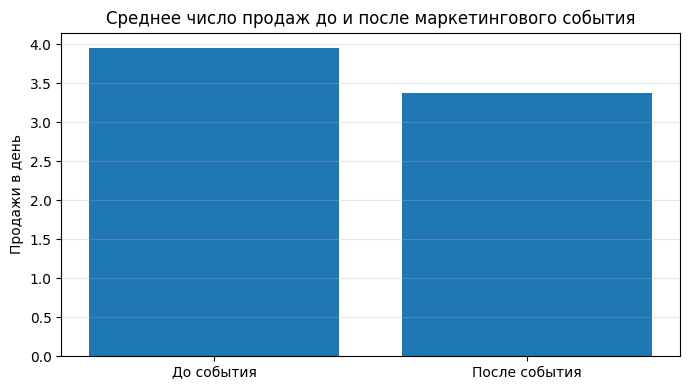

In [28]:
plt.figure(figsize=(7, 4))

plt.bar(
    overall["period"],
    overall["transactions"]
)

plt.title("Среднее число продаж до и после маркетингового события")
plt.ylabel("Продажи в день")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

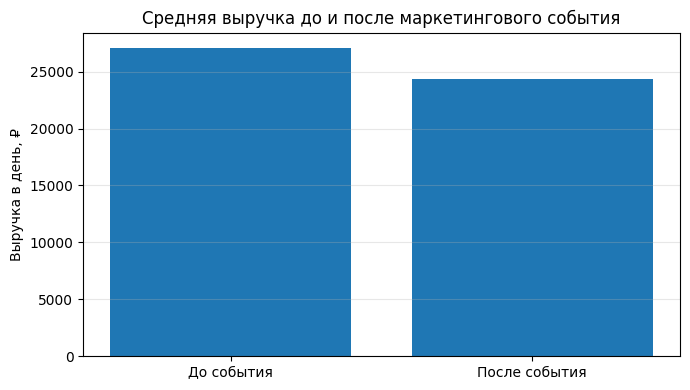

In [29]:
plt.figure(figsize=(7, 4))

plt.bar(
    overall["period"],
    overall["revenue"]
)

plt.title("Средняя выручка до и после маркетингового события")
plt.ylabel("Выручка в день, ₽")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
activity_effect = (
    event_sales
    .groupby("activity_type", as_index=False)
    .agg(
        events=("event_id", "nunique"),
        avg_uplift_transactions=("uplift_transactions_abs", "mean"),
        median_uplift_transactions=("uplift_transactions_abs", "median"),
        avg_uplift_revenue=("uplift_revenue_abs", "mean")
    )
    .sort_values("avg_uplift_revenue", ascending=False)
)

display(activity_effect)

,activity_type,events,avg_uplift_transactions,median_uplift_transactions,avg_uplift_revenue
1,Запуск / набор (авто),2,2.94,2.33,"23,571.58"
0,Бесплатное событие / лид-магнит (авто),4,0.90,0.17,"7,543.25"
2,Контент с предложением курсов (авто),12,0.13,0.00,-202.01
3,Контент со ссылкой / упоминанием,3,-0.75,-0.50,"-4,667.75"
4,Продвижение курсов / промо (кандидат по тексту),57,-0.91,-0.67,"-4,989.32"
5,Промо со скидкой (авто),4,-2.70,-2.00,"-12,357.61"


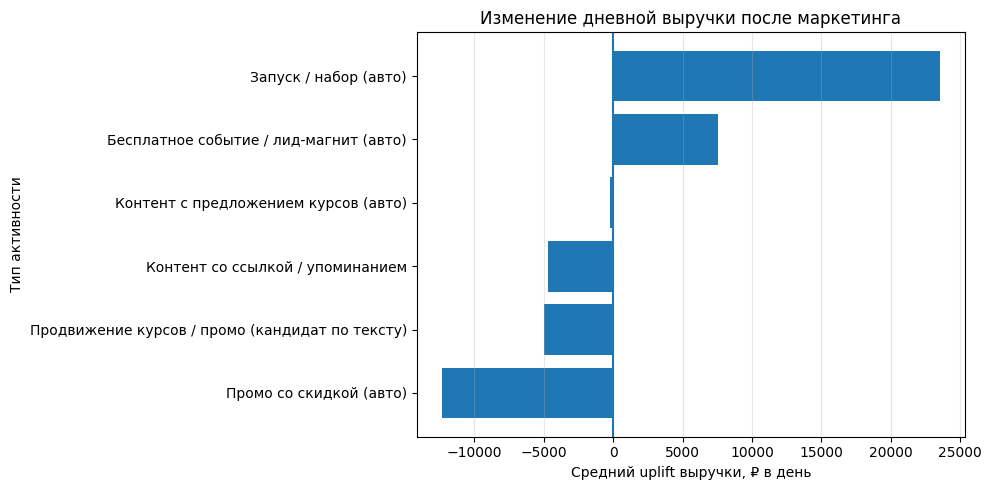

In [31]:
plot_data = activity_effect.sort_values("avg_uplift_revenue")

plt.figure(figsize=(10, 5))

plt.barh(
    plot_data["activity_type"],
    plot_data["avg_uplift_revenue"]
)

plt.axvline(0)

plt.title("Изменение дневной выручки после маркетинга")
plt.xlabel("Средний uplift выручки, ₽ в день")
plt.ylabel("Тип активности")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
course_effect = (
    event_sales
    .groupby("candidate_course", as_index=False)
    .agg(
        events=("event_id", "nunique"),
        avg_before=("avg_transactions_before", "mean"),
        avg_after=("avg_transactions_after", "mean"),
        avg_uplift_transactions=("uplift_transactions_abs", "mean"),
        avg_uplift_revenue=("uplift_revenue_abs", "mean")
    )
    .sort_values("avg_uplift_transactions", ascending=False)
)

display(course_effect)

,candidate_course,events,avg_before,avg_after,avg_uplift_transactions,avg_uplift_revenue
3,ML про,36,3.53,4.25,0.72,"5,763.33"
5,А/В-тесты,5,0.20,0.20,0.00,298.67
6,Алгоритмы про,37,1.45,1.44,-0.01,260.01
8,Аналитика про,37,4.11,4.08,-0.03,215.38
1,Backend про,39,2.48,2.23,-0.25,"-1,967.37"
0,AI-агенты про,38,3.94,3.64,-0.30,"-2,875.07"
4,ML старт,18,6.56,5.69,-0.87,"-2,784.26"
9,Аналитика старт,21,5.08,4.21,-0.87,"-3,012.46"
7,Алгоритмы старт,20,8.87,5.87,-3.00,"-14,192.75"
2,Backend старт,19,4.47,1.07,-3.40,"-20,284.85"


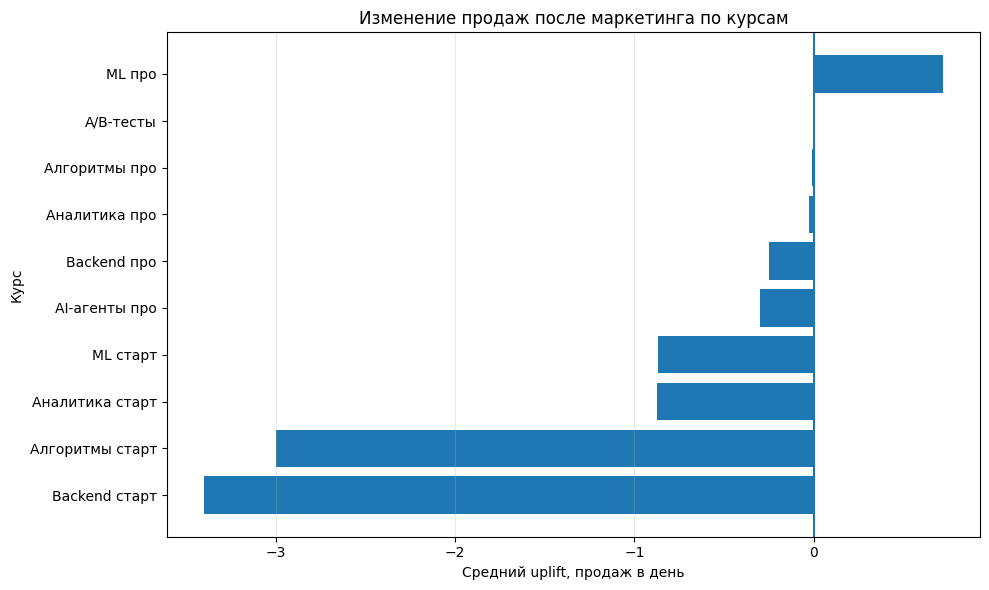

In [33]:
plot_data = course_effect.sort_values("avg_uplift_transactions")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["candidate_course"],
    plot_data["avg_uplift_transactions"]
)

plt.axvline(0)

plt.title("Изменение продаж после маркетинга по курсам")
plt.xlabel("Средний uplift, продаж в день")
plt.ylabel("Курс")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
line_effect = (
    event_sales
    .dropna(subset=["product_line"])
    .groupby("product_line", as_index=False)
    .agg(
        events=("event_id", "nunique"),
        avg_before=("avg_transactions_before", "mean"),
        avg_after=("avg_transactions_after", "mean"),
        avg_uplift_transactions=("uplift_transactions_abs", "mean"),
        avg_uplift_revenue=("uplift_revenue_abs", "mean")
    )
)

display(line_effect)

,product_line,events,avg_before,avg_after,avg_uplift_transactions,avg_uplift_revenue
0,PRO,53,3.08,3.04,-0.04,-306.80
1,START,24,6.36,4.24,-2.12,"-10,514.63"
2,START | PRO,3,1.81,3.90,2.10,"16,780.48"


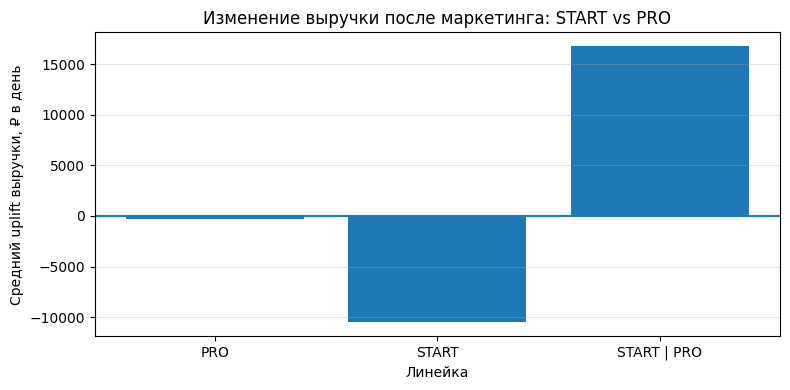

In [35]:
plt.figure(figsize=(8, 4))

plt.bar(
    line_effect["product_line"],
    line_effect["avg_uplift_revenue"]
)

plt.axhline(0)

plt.title("Изменение выручки после маркетинга: START vs PRO")
plt.xlabel("Линейка")
plt.ylabel("Средний uplift выручки, ₽ в день")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
positive_share = (
    (event_sales["uplift_transactions_abs"] > 0)
    .mean()
    * 100
)

print(
    f"Доля событий, после которых продажи выросли: "
    f"{positive_share:.1f}%"
)

Доля событий, после которых продажи выросли: 43.7%


In [37]:
positive_revenue_share = (
    (event_sales["uplift_revenue_abs"] > 0)
    .mean()
    * 100
)

print(
    f"Доля событий, после которых выросла выручка: "
    f"{positive_revenue_share:.1f}%"
)

Доля событий, после которых выросла выручка: 48.1%


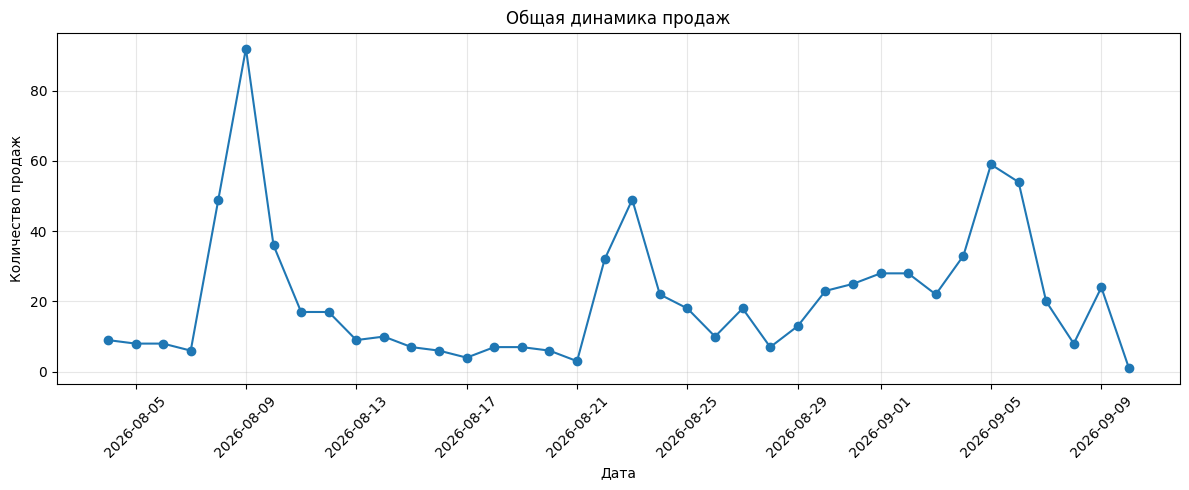

In [38]:
daily_total = (
    sales
    .assign(date=sales["timestamp"].dt.floor("D"))
    .groupby("date", as_index=False)
    .agg(
        transactions=("student_id", "size"),
        revenue=("amount", "sum")
    )
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    daily_total["date"],
    daily_total["transactions"],
    marker="o"
)

ax.set_title("Общая динамика продаж")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество продаж")
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
def get_product_line(course):
    course = str(course).lower()

    if "старт" in course:
        return "START"

    if "про" in course or "ai-агенты" in course:
        return "PRO"

    return "OTHER"

sales["product_line"] = (
    sales["course_normalized"]
    .apply(get_product_line)
)

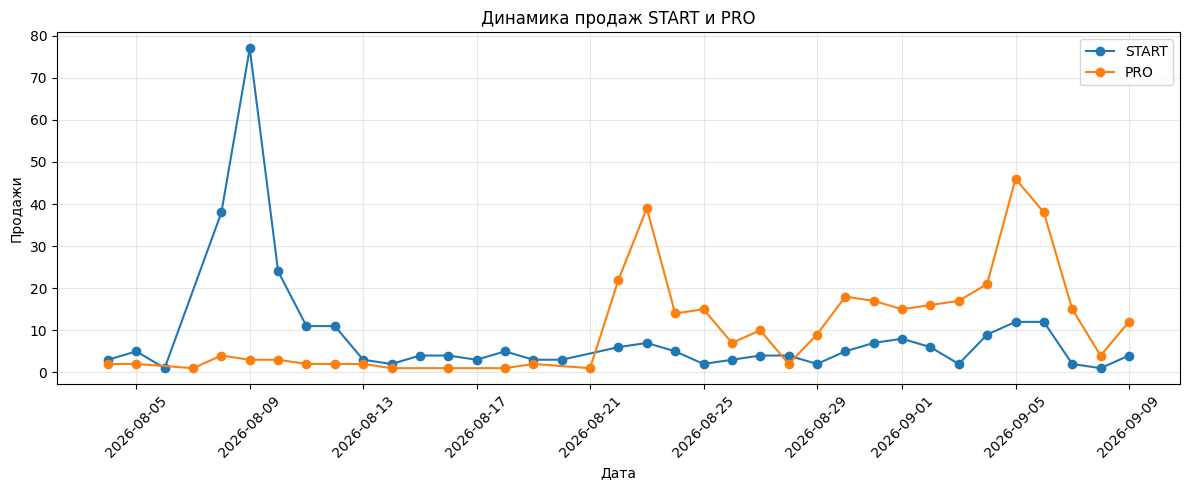

In [40]:
daily_line = (
    sales
    .assign(date=sales["timestamp"].dt.floor("D"))
    .groupby(
        ["date", "product_line"],
        as_index=False
    )
    .agg(
        transactions=("student_id", "size")
    )
)

fig, ax = plt.subplots(figsize=(12, 5))

for line in ["START", "PRO"]:
    subset = daily_line[
        daily_line["product_line"] == line
    ]

    ax.plot(
        subset["date"],
        subset["transactions"],
        marker="o",
        label=line
    )

ax.set_title("Динамика продаж START и PRO")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
events_daily = (
    marketing_courses
    .assign(date=marketing_courses["event_time"].dt.floor("D"))
    .groupby("date")
    .agg(
        events=("event_id", "nunique"),
        course_mentions=("candidate_course", "size")
    )
    .reset_index()
)

events_daily.sort_values(
    "events",
    ascending=False
).head(15)

,date,events,course_mentions
4,2026-08-10,13,46
10,2026-08-23,7,12
24,2026-09-07,6,12
21,2026-09-03,6,23
2,2026-08-08,5,18
20,2026-09-02,5,21
23,2026-09-06,4,16
16,2026-08-29,3,15
3,2026-08-09,3,9
9,2026-08-22,3,8


In [42]:
marketing_course_daily = (
    marketing_courses
    .assign(date=marketing_courses["event_time"].dt.floor("D"))
    .groupby(
        ["date", "candidate_course"],
        as_index=False
    )
    .agg(
        marketing_events=("event_id", "nunique"),
        activity_types=(
            "activity_type",
            lambda x: " | ".join(sorted(set(x.dropna())))
        )
    )
)

marketing_course_daily.head()

,date,candidate_course,marketing_events,activity_types
0,2026-08-05,AI-агенты про,1,Продвижение курсов / промо (кандидат по тексту)
1,2026-08-05,Backend про,1,Продвижение курсов / промо (кандидат по тексту)
2,2026-08-05,ML про,1,Продвижение курсов / промо (кандидат по тексту)
3,2026-08-05,Алгоритмы про,1,Продвижение курсов / промо (кандидат по тексту)
4,2026-08-05,Аналитика про,1,Продвижение курсов / промо (кандидат по тексту)


In [43]:
marketing_course_daily["marketing_events"].describe()

count   119.00
mean      2.27
std       2.06
min       1.00
25%       1.00
50%       2.00
75%       3.00
max      12.00
Name: marketing_events, dtype: float64

In [44]:
marketing_course_daily.sort_values(
    "marketing_events",
    ascending=False
).head(20)

,date,candidate_course,marketing_events,activity_types
18,2026-08-10,Аналитика старт,12,Продвижение курсов / промо (кандидат по тексту...
17,2026-08-10,Алгоритмы старт,12,Продвижение курсов / промо (кандидат по тексту...
16,2026-08-10,ML старт,11,Продвижение курсов / промо (кандидат по тексту...
15,2026-08-10,Backend старт,11,Продвижение курсов / промо (кандидат по тексту...
84,2026-09-02,AI-агенты про,5,Бесплатное событие / лид-магнит (авто) | Продв...
8,2026-08-08,ML старт,5,Продвижение курсов / промо (кандидат по тексту)
89,2026-09-03,AI-агенты про,5,Контент с предложением курсов (авто) | Продвиж...
9,2026-08-08,Алгоритмы старт,5,Продвижение курсов / промо (кандидат по тексту)
87,2026-09-02,Алгоритмы про,5,Бесплатное событие / лид-магнит (авто) | Продв...
7,2026-08-08,Backend старт,4,Продвижение курсов / промо (кандидат по тексту)


In [45]:
analysis_daily = marketing_course_daily.merge(
    sales_daily,
    left_on=["date", "candidate_course"],
    right_on=["date", "course_normalized"],
    how="left"
)

analysis_daily[
    ["date", "candidate_course", "marketing_events", "transactions", "revenue"]
].head(20)

,date,candidate_course,marketing_events,transactions,revenue
0,2026-08-05,AI-агенты про,1,NaN,NaN
1,2026-08-05,Backend про,1,2.00,"16,450.00"
2,2026-08-05,ML про,1,NaN,NaN
3,2026-08-05,Алгоритмы про,1,NaN,NaN
4,2026-08-05,Аналитика про,1,NaN,NaN
5,2026-08-07,ML про,1,1.00,"8,745.00"
6,2026-08-07,Алгоритмы старт,1,NaN,NaN
7,2026-08-08,Backend старт,4,8.00,"45,850.00"
8,2026-08-08,ML старт,5,9.00,"48,130.00"
9,2026-08-08,Алгоритмы старт,5,14.00,"72,565.00"


Маркетинговые события распределены по времени неравномерно и часто концентрируются в одни и те же даты. 
Например, 10.08 зафиксировано 13 маркетинговых событий и 46 упоминаний курсов.

Из-за этого простая схема «одно событие → продажи после него» приводит к сильному пересечению окон и многократному учёту одних и тех же продаж.

Поэтому дальнейший анализ проводится на уровне `дата × курс`, а не отдельного `event_id`.

In [46]:
LAG_BEFORE = 3
LAG_AFTER = 7

event_study_rows = []

for _, row in marketing_course_daily.iterrows():
    event_date = row["date"]
    course = row["candidate_course"]

    course_sales = sales_daily[
        sales_daily["course_normalized"] == course
    ]

    for lag in range(-LAG_BEFORE, LAG_AFTER + 1):
        target_date = event_date + pd.Timedelta(days=lag)

        day_sales = course_sales[
            course_sales["date"] == target_date
        ]

        if len(day_sales) > 0:
            transactions = day_sales["transactions"].sum()
            buyers = day_sales["buyers"].sum()
            revenue = day_sales["revenue"].sum()
        else:
            transactions = 0
            buyers = 0
            revenue = 0

        event_study_rows.append({
            "event_date": event_date,
            "candidate_course": course,
            "lag": lag,
            "marketing_events": row["marketing_events"],
            "transactions": transactions,
            "buyers": buyers,
            "revenue": revenue,
        })

event_study = pd.DataFrame(event_study_rows)

event_study.head(15)

,event_date,candidate_course,lag,marketing_events,transactions,buyers,revenue
0,2026-08-05,AI-агенты про,-3,1,0,0,0.00
1,2026-08-05,AI-агенты про,-2,1,0,0,0.00
2,2026-08-05,AI-агенты про,-1,1,0,0,0.00
3,2026-08-05,AI-агенты про,0,1,0,0,0.00
4,2026-08-05,AI-агенты про,1,1,0,0,0.00
5,2026-08-05,AI-агенты про,2,1,0,0,0.00
6,2026-08-05,AI-агенты про,3,1,0,0,0.00
7,2026-08-05,AI-агенты про,4,1,0,0,0.00
8,2026-08-05,AI-агенты про,5,1,0,0,0.00
9,2026-08-05,AI-агенты про,6,1,0,0,0.00


In [47]:
event_study_summary = (
    event_study
    .groupby("lag", as_index=False)
    .agg(
        avg_transactions=("transactions", "mean"),
        median_transactions=("transactions", "median"),
        avg_buyers=("buyers", "mean"),
        avg_revenue=("revenue", "mean"),
        observations=("candidate_course", "size"),
    )
)

event_study_summary

,lag,avg_transactions,median_transactions,avg_buyers,avg_revenue,observations
0,-3,2.21,1.00,2.21,"17,414.19",119
1,-2,2.67,1.00,2.67,"20,574.17",119
2,-1,3.39,1.00,3.39,"24,346.64",119
3,0,3.82,2.00,3.82,"27,368.51",119
4,1,3.27,2.00,3.27,"23,294.33",119
5,2,2.58,1.00,2.58,"19,268.76",119
6,3,2.34,1.00,2.34,"18,018.42",119
7,4,2.18,1.00,2.18,"17,072.92",119
8,5,2.02,1.00,2.02,"15,885.74",119
9,6,2.15,1.00,2.15,"16,983.28",119


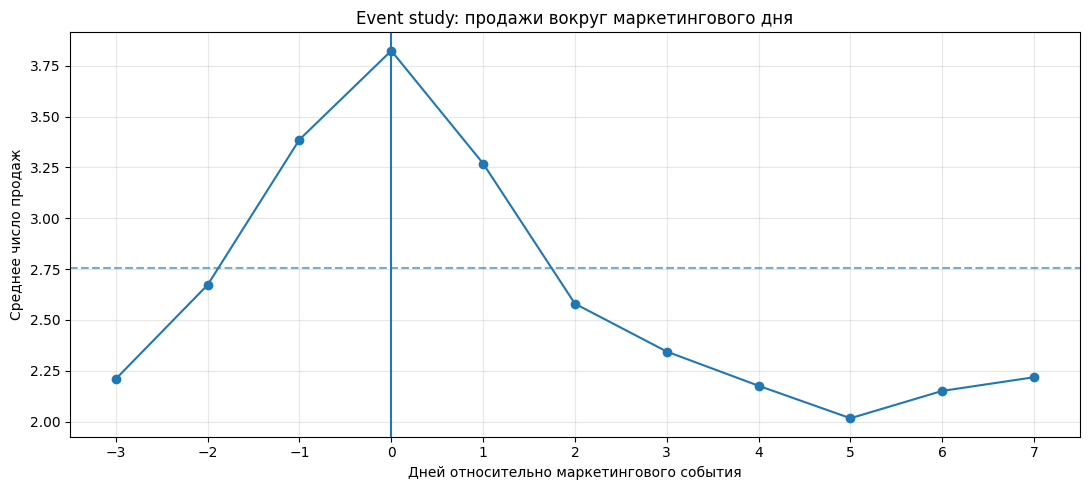

In [48]:
plt.figure(figsize=(11, 5))

plt.plot(
    event_study_summary["lag"],
    event_study_summary["avg_transactions"],
    marker="o"
)

plt.axvline(0)
plt.axhline(
    event_study_summary.loc[
        event_study_summary["lag"] < 0,
        "avg_transactions"
    ].mean(),
    linestyle="--",
    alpha=0.6
)

plt.title("Event study: продажи вокруг маркетингового дня")
plt.xlabel("Дней относительно маркетингового события")
plt.ylabel("Среднее число продаж")
plt.xticks(range(-LAG_BEFORE, LAG_AFTER + 1))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

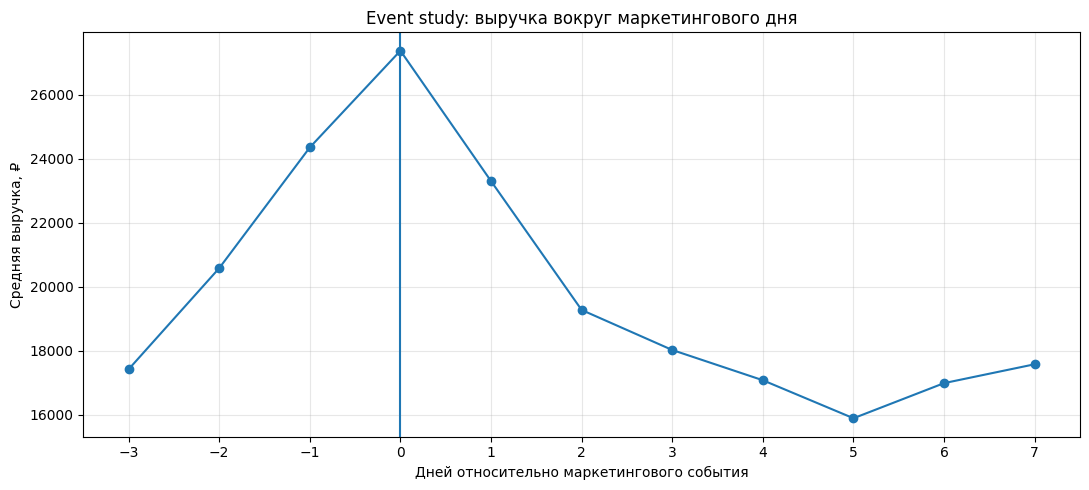

In [49]:
plt.figure(figsize=(11, 5))

plt.plot(
    event_study_summary["lag"],
    event_study_summary["avg_revenue"],
    marker="o"
)

plt.axvline(0)

plt.title("Event study: выручка вокруг маркетингового дня")
plt.xlabel("Дней относительно маркетингового события")
plt.ylabel("Средняя выручка, ₽")
plt.xticks(range(-LAG_BEFORE, LAG_AFTER + 1))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
baseline_transactions = (
    event_study_summary.loc[
        event_study_summary["lag"] < 0,
        "avg_transactions"
    ]
    .mean()
)

baseline_revenue = (
    event_study_summary.loc[
        event_study_summary["lag"] < 0,
        "avg_revenue"
    ]
    .mean()
)

baseline_transactions, baseline_revenue

(2.756302521008404, 20778.332408963586)

In [51]:
event_study_summary["transactions_index"] = (
    event_study_summary["avg_transactions"]
    / baseline_transactions
    * 100
)

event_study_summary["revenue_index"] = (
    event_study_summary["avg_revenue"]
    / baseline_revenue
    * 100
)

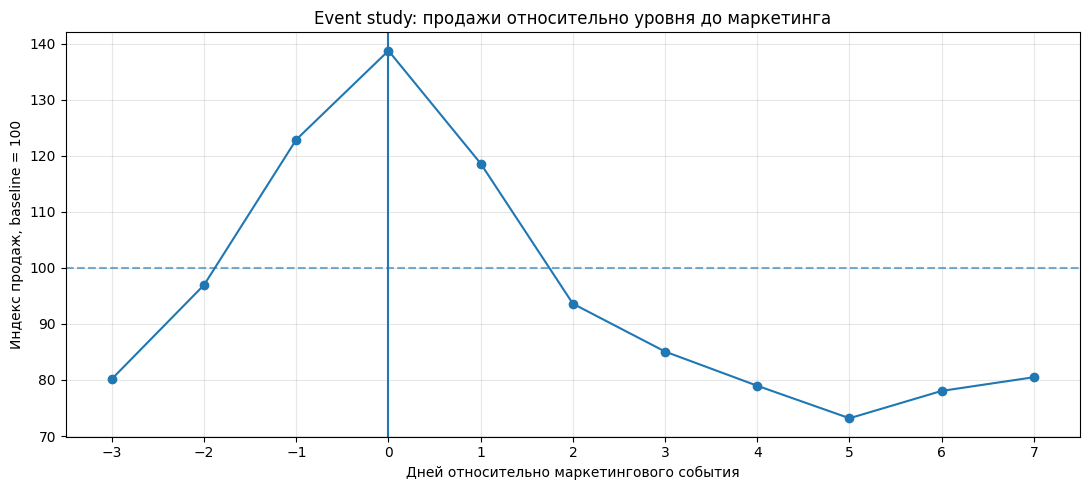

In [52]:
plt.figure(figsize=(11, 5))

plt.plot(
    event_study_summary["lag"],
    event_study_summary["transactions_index"],
    marker="o"
)

plt.axhline(100, linestyle="--", alpha=0.6)
plt.axvline(0)

plt.title("Event study: продажи относительно уровня до маркетинга")
plt.xlabel("Дней относительно маркетингового события")
plt.ylabel("Индекс продаж, baseline = 100")
plt.xticks(range(-LAG_BEFORE, LAG_AFTER + 1))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Вывод

В среднем продажи начинают расти ещё до зафиксированного маркетингового события,
достигают максимума в день события (`D0`) и остаются повышенными на следующий день (`D+1`).
После `D+1` наблюдается снижение продаж.

При этом наличие роста уже на `D-1` указывает на выраженный pre-trend.
Поэтому пик в `D0` нельзя интерпретировать как причинный эффект одного конкретного
маркетингового события.

Вероятные причины — пересечение нескольких маркетинговых активностей,
предшествующий прогрев аудитории и концентрация событий в одни и те же даты.